In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (3).jpeg
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im01.png
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im05.jpg
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im02small.png
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/q2.jpeg
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/shells.tif
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/q1.jpeg
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im04small.jpg
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.43 (1).jpeg
/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsAp

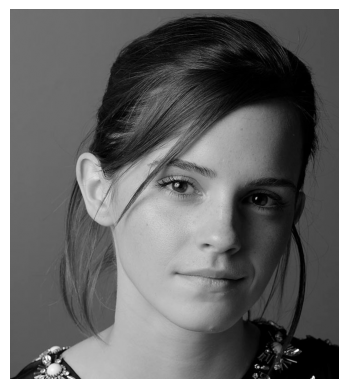

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread("/kaggle/input/datasets/isithadinujaya/cv-images/emma.jpg", cv.IMREAD_GRAYSCALE)

plt.imshow(im, cmap="gray")
plt.axis("off")
plt.show()

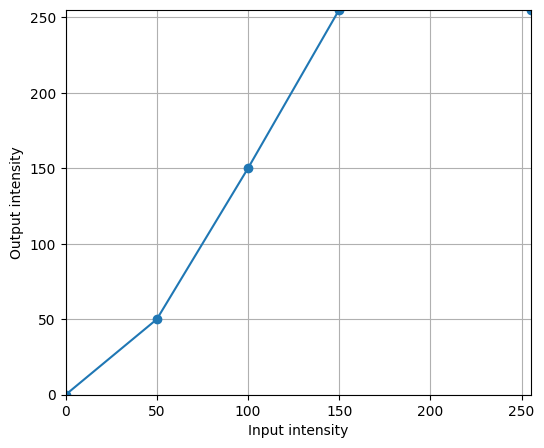

In [3]:
breakpoints = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
])
def intensity_transform(im, breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]
    transformed = np.interp(im, x, y)
    return transformed.astype(np.uint8)

im_transformed = intensity_transform(im, breakpoints)

plt.figure(figsize=(6, 5))
plt.plot(breakpoints[:, 0],
         breakpoints[:, 1],
         marker='o')

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()
plt.show()

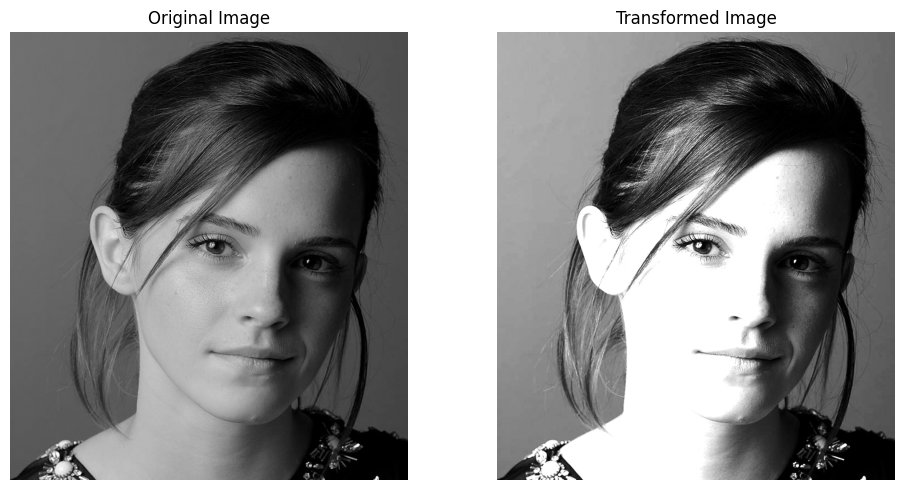

In [4]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(im_transformed, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# # **Question 2**

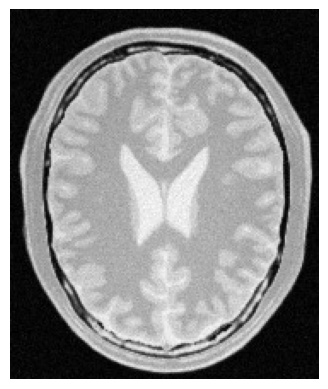

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

brain = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/q2.jpeg", cv.IMREAD_GRAYSCALE)

plt.imshow(brain, cmap="gray")
plt.axis("off")
plt.show()

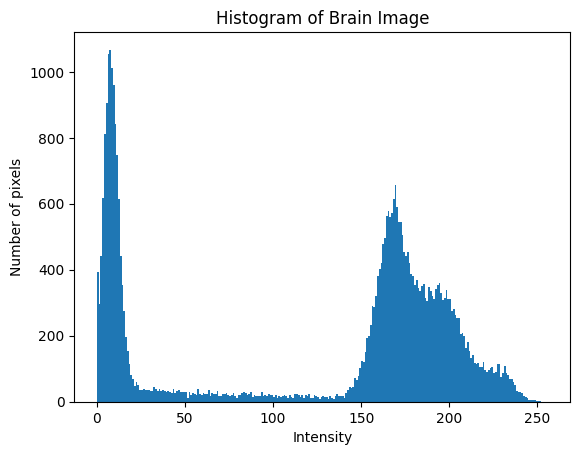

In [6]:
plt.hist(brain.ravel(), bins=256, range=[0, 256])

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Brain Image")
plt.show()

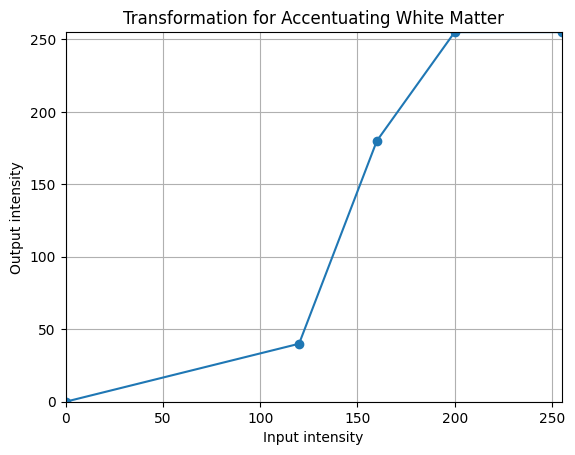

In [7]:
def intensity_transform(im, breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    transformed = np.interp(im, x, y)

    return transformed.astype(np.uint8)

bp_white = np.array([
    [0,   0],
    [120, 40],
    [160, 180],
    [200, 255],
    [255, 255]
])

white_result = intensity_transform(brain, bp_white)

plt.plot(bp_white[:, 0], bp_white[:, 1], marker='o')

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transformation for Accentuating White Matter")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

plt.show()

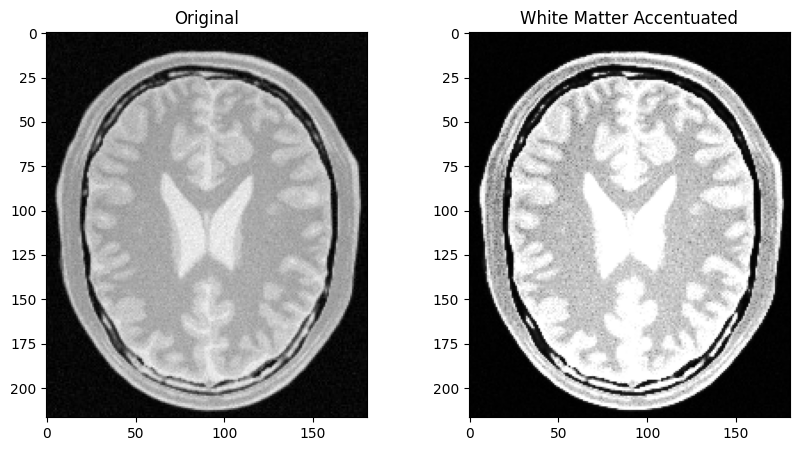

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(white_result, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Accentuated")

plt.show()

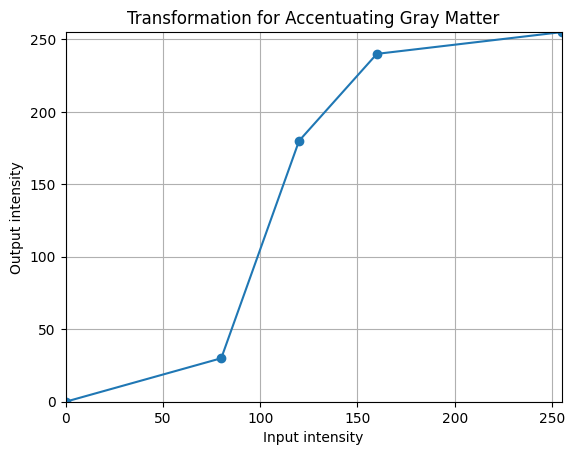

In [9]:
bp_gray = np.array([
    [0,   0],
    [80,  30],
    [120, 180],
    [160, 240],
    [255, 255]
])

gray_result = intensity_transform(brain, bp_gray)

plt.plot(bp_gray[:, 0], bp_gray[:, 1], marker='o')

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transformation for Accentuating Gray Matter")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

plt.show()

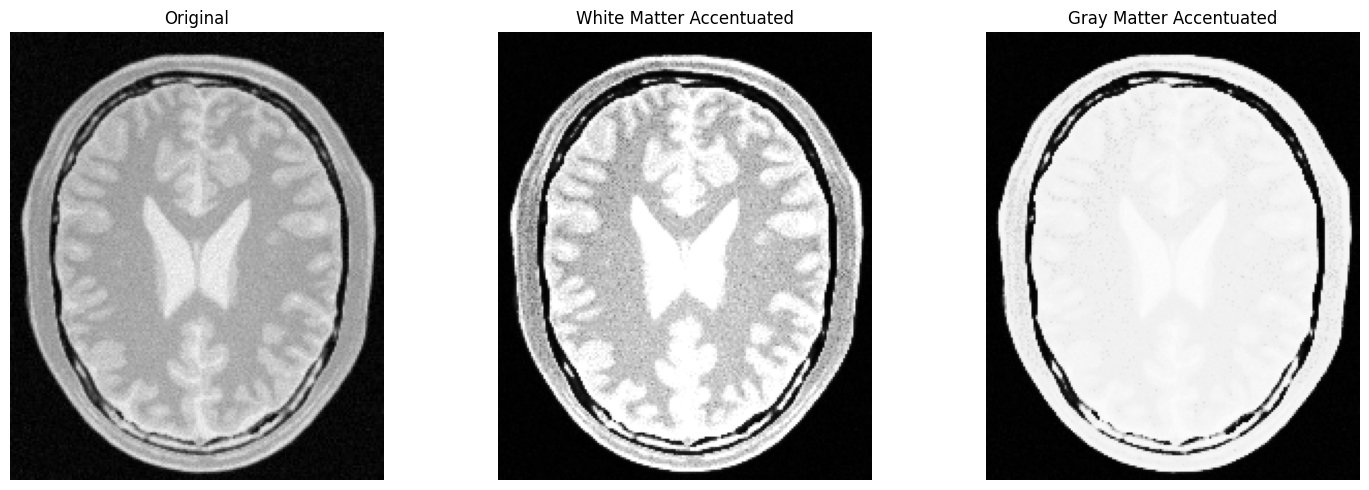

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(white_result, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Accentuated")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_result, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()